In [3]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
%matplotlib inline
import dmba

In [5]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [7]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pylab as plt
%matplotlib inline
import dmba
from dmba import plotDecisionTree, classificationSummary

In [9]:
housing_df = pd.read_excel(r"C:\Users\Akash\OneDrive\Desktop\Intro to Machine Learning\Datsets\Final Project\Nashville Housing Datasets.xlsx")


In [11]:
housing_df.shape

(56159, 21)

In [13]:
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56159 entries, 0 to 56158
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   UniqueID               56159 non-null  int64         
 1   ParcelID               56159 non-null  object        
 2   LandUse                56159 non-null  object        
 3   SalePrice              56159 non-null  int64         
 4   LegalReference         56159 non-null  object        
 5   SoldAsVacant           56159 non-null  object        
 6   SoldAsVacant Brackets  56159 non-null  int64         
 7   OwnerName              56159 non-null  object        
 8   LandValue              56159 non-null  int64         
 9   BuildingValue          56159 non-null  int64         
 10  TotalValue             56159 non-null  int64         
 11  YearBuilt              56159 non-null  int64         
 12  Bedrooms               56159 non-null  int64         
 13  F

In [15]:
housing_df.dtypes

UniqueID                          int64
ParcelID                         object
LandUse                          object
SalePrice                         int64
LegalReference                   object
SoldAsVacant                     object
SoldAsVacant Brackets             int64
OwnerName                        object
LandValue                         int64
BuildingValue                     int64
TotalValue                        int64
YearBuilt                         int64
Bedrooms                          int64
FullBath                          int64
HalfBath                          int64
Sale Date                datetime64[ns]
Property Address                 object
Property City                    object
Owner-Address                    object
Owner-City                       object
Owner-State                      object
dtype: object

In [17]:
housing_df.columns # space issue

Index(['UniqueID', 'ParcelID', 'LandUse', 'SalePrice', 'LegalReference',
       'SoldAsVacant', 'SoldAsVacant Brackets', 'OwnerName', 'LandValue',
       'BuildingValue', 'TotalValue', 'YearBuilt', 'Bedrooms', 'FullBath',
       'HalfBath', 'Sale Date', 'Property Address', 'Property City',
       'Owner-Address', 'Owner-City', 'Owner-State'],
      dtype='object')

In [19]:
housing_df.columns = [name.strip().replace(" ", "_") for name in housing_df.columns]

In [21]:
object_cols = housing_df.select_dtypes(include='object').columns
print(object_cols)


Index(['ParcelID', 'LandUse', 'LegalReference', 'SoldAsVacant', 'OwnerName',
       'Property_Address', 'Property_City', 'Owner-Address', 'Owner-City',
       'Owner-State'],
      dtype='object')


In [23]:
for col in object_cols:
   housing_df[col] = housing_df[col].astype('category')


In [25]:
housing_df.dtypes

UniqueID                          int64
ParcelID                       category
LandUse                        category
SalePrice                         int64
LegalReference                 category
SoldAsVacant                   category
SoldAsVacant_Brackets             int64
OwnerName                      category
LandValue                         int64
BuildingValue                     int64
TotalValue                        int64
YearBuilt                         int64
Bedrooms                          int64
FullBath                          int64
HalfBath                          int64
Sale_Date                datetime64[ns]
Property_Address               category
Property_City                  category
Owner-Address                  category
Owner-City                     category
Owner-State                    category
dtype: object

## Feauture Engineering 

In [27]:
housing_df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)


SalePrice                1.000000
TotalValue               0.166741
BuildingValue            0.146669
LandValue                0.146287
FullBath                 0.117501
Bedrooms                 0.075152
HalfBath                 0.029584
UniqueID                 0.017403
YearBuilt                0.003112
SoldAsVacant_Brackets   -0.005836
Name: SalePrice, dtype: float64

In [29]:
housing_df['TotalBaths'] = housing_df['FullBath'] + 0.5 * housing_df['HalfBath']


In [31]:
housing_df['New_Age'] = 2025 - housing_df['YearBuilt']


In [33]:
housing_df['Built_Before_2015'] = housing_df['YearBuilt'].apply(lambda x: 1 if x <= 2015 else 0)


In [35]:

housing_df['Sale_Date'] = pd.to_datetime(housing_df['Sale_Date'])

housing_df['SaleMonth'] = housing_df['Sale_Date'].dt.month

housing_df['Is_Summer_Sale'] = housing_df['SaleMonth'].apply(lambda x: 1 if x >= 5 and x <= 8 else 0)


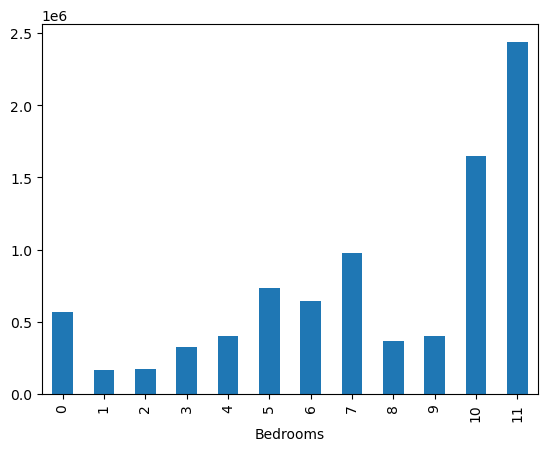

In [52]:
housing_df.groupby('Bedrooms')['SalePrice'].mean().plot(kind='bar')
plt.show()


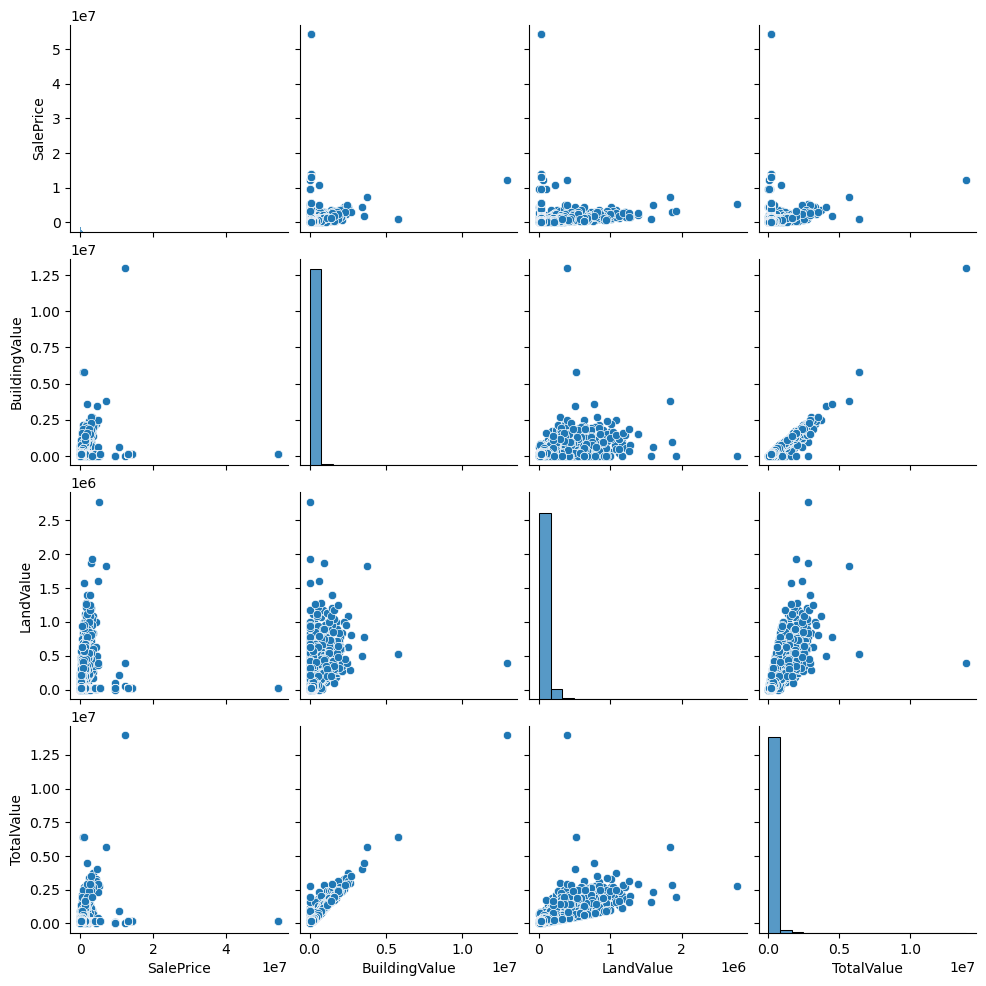

In [123]:
sns.pairplot(housing_df[['SalePrice', 'BuildingValue', 'LandValue', 'TotalValue']])
plt.show()

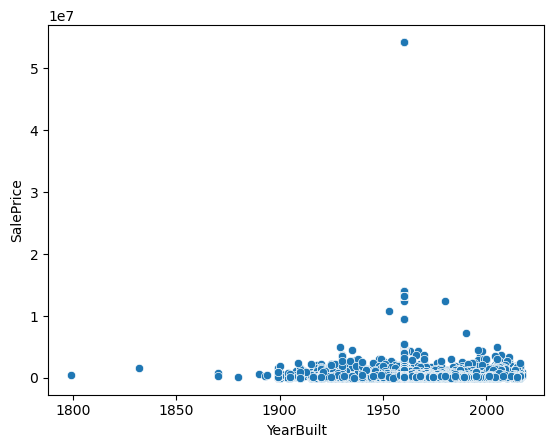

In [125]:
sns.scatterplot(x='YearBuilt', y='SalePrice', data=housing_df)
plt.show()

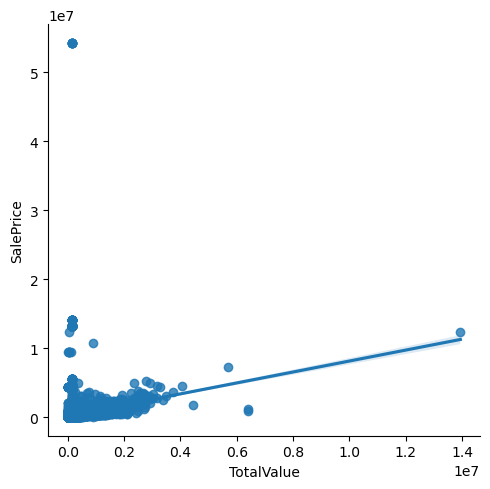

In [127]:
sns.lmplot(x='TotalValue', y='SalePrice', data=housing_df)
plt.show()

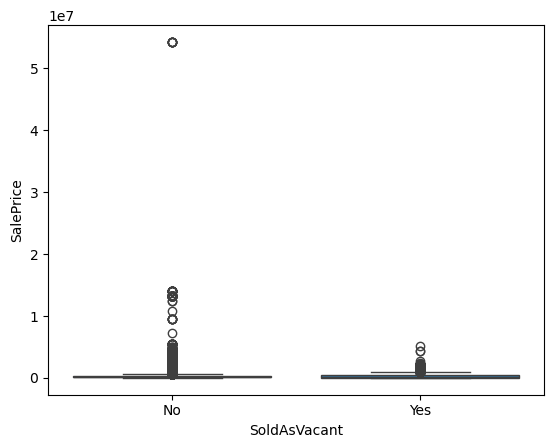

In [129]:
sns.boxplot(x='SoldAsVacant', y='SalePrice', data=housing_df)
plt.show()


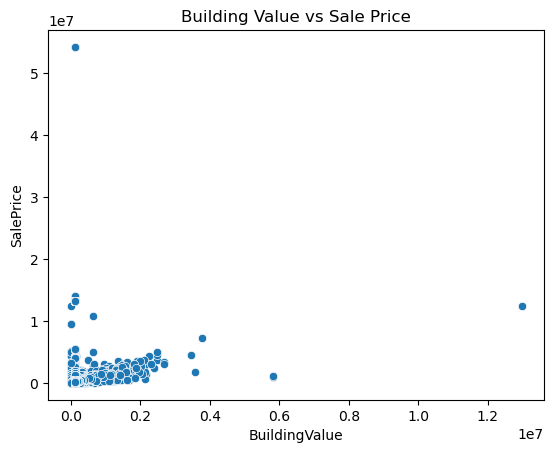

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(data=housing_df, x='BuildingValue', y='SalePrice')
plt.title("Building Value vs Sale Price")
plt.show()


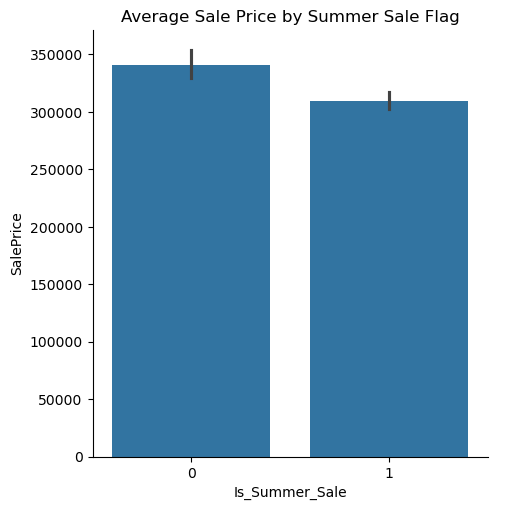

In [141]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.catplot(x='Is_Summer_Sale', y='SalePrice', data=housing_df, kind='bar')
plt.title('Average Sale Price by Summer Sale Flag')
plt.show()


## Linear Regression

In [211]:

columns_to_drop = ['Owner-City', 'Owner-State','ParcelID','LegalReference','OwnerName','SoldAsVacant','Property_Address','Owner-Address','Sale_Date']  

housing_df_reduced = housing_df.drop(columns=columns_to_drop)

housing_df_encoded = pd.get_dummies(housing_df_reduced, drop_first=True)


In [213]:
housing_df_encoded.dtypes

UniqueID                       int64
SalePrice                      int64
SoldAsVacant_Brackets          int64
LandValue                      int64
BuildingValue                  int64
                               ...  
Property_City_ NASHVILLE        bool
Property_City_ NOLENSVILLE      bool
Property_City_ OLD HICKORY      bool
Property_City_ UNKNOWN          bool
Property_City_ WHITES CREEK     bool
Length: 69, dtype: object

In [215]:
import numpy as np

housing_df['Log_SalePrice'] = np.log1p(housing_df['SalePrice'])  
y = housing_df['Log_SalePrice']


In [169]:
housing_df_encoded['Log_SalePrice'] = np.log1p(housing_df['SalePrice'])


In [217]:
features = ['TotalValue', 'LandValue', 'BuildingValue', 'TotalBaths', 
            'YearBuilt', 'Bedrooms', 'New_Age', 'Is_Summer_Sale']


In [219]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

X = housing_df_encoded[features]
y = housing_df_encoded['Log_SalePrice']  # log-transformed

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred_log = model.predict(X_test)


In [221]:

y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

mae = mean_absolute_error(y_test_original, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred))
mape = np.mean(np.abs((y_test_original - y_pred) / y_test_original)) * 100

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")


MAE: 243853.93
RMSE: 3883869.76
MAPE: 90.38%


## Neural Networks

In [223]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [225]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.model_selection import train_test_split
import dmba
from dmba import classificationSummary
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler

In [227]:
df = housing_df.copy()

In [229]:
df = df.drop(columns=['Owner-City', 'Owner-State','ParcelID','LegalReference','OwnerName','SoldAsVacant','Property_Address','Owner-Address','Sale_Date'],errors='ignore')


In [231]:
X_orginal = df.drop(columns=['SalePrice'])
y = df['SalePrice']



In [233]:
X = pd.get_dummies(X_orginal, drop_first=True)

In [235]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [237]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)


In [239]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [287]:
nn1=MLPRegressor(hidden_layer_sizes=(50,25,),activation='relu',solver='adam',random_state=100)
nn1.fit(X_train_scaled,y_train_log)

MLPRegressor(hidden_layer_sizes=(50, 25), random_state=100)

In [289]:
preds_log = nn1.predict(X_test_scaled)
preds = np.expm1(preds_log)  # convert back to original scale


In [291]:

mse = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)  
r2 = r2_score(y_test, preds)  

print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(nn1, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"Cross-Validation R^2 Scores: {cv_scores}")
print(f"Mean Cross-Validation R^2 Score: {cv_scores.mean()}")


MSE: 59168254.35968707
RMSE: 7692.090376463804
R² Score: 0.9999496843455762


C:\Users\Akash\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Akash\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Akash\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Akash\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Cross-Validation R^2 Scores: [0.08998772 0.06831681 0.10006222 0.06210893 0.06553884]
Mean Cross-Validation R^2 Score: 0.07720290310051758


C:\Users\Akash\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


# KMeans Clustering

In [147]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


In [149]:
features = [
    'LandValue',
    'BuildingValue',
    'YearBuilt',
    'Bedrooms',
    'TotalBaths',
    'New_Age',
    'Built_Before_2015'
]
X = housing_df[features]


In [151]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


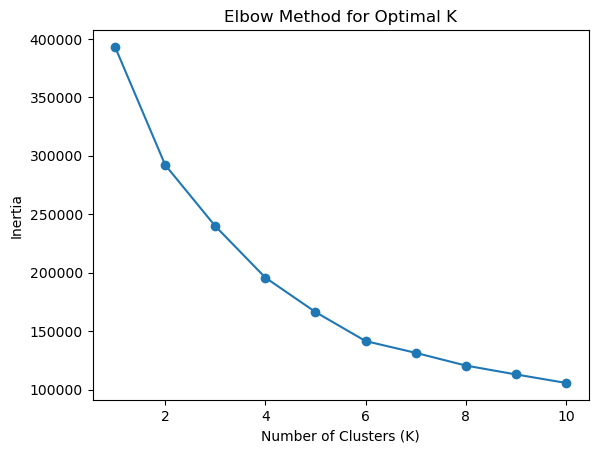

In [153]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()


In [155]:
kmeans = KMeans(n_clusters=3, random_state=42)
housing_df['Cluster'] = kmeans.fit_predict(X_scaled)


In [171]:
housing_df.groupby('Cluster')[features + ['Log_SalePrice']].mean()


,LandValue,BuildingValue,YearBuilt,Bedrooms,TotalBaths,New_Age,Built_Before_2015,Log_SalePrice
Cluster,,,,,,,,
0,36336.222000,110436.617733,1958.695342,2.958309,1.877354,66.304658,1.0,12.203341
1,165039.231664,367086.577594,1987.045394,3.891547,3.378801,37.954606,1.0,12.869821
2,99388.107203,420671.021776,2016.021776,3.581240,3.300670,8.978224,0.0,12.362252


In [173]:
# Filter to only premium homes (Cluster 1)
premium_homes = housing_df[housing_df['Cluster'] == 1]

# Count number of premium homes in each city
premium_by_city = premium_homes['Property_City'].value_counts().sort_values(ascending=False)

# Display top cities with most premium homes
print(premium_by_city.head(10))


Property_City
NASHVILLE         3780
ANTIOCH            170
HERMITAGE          136
BRENTWOOD          133
OLD HICKORY        106
MADISON             83
GOODLETTSVILLE      58
WHITES CREEK         3
MOUNT JULIET         2
NOLENSVILLE          1
Name: count, dtype: int64


C:\Users\Akash\AppData\Local\Temp\ipykernel_27732\2019652813.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=premium_by_city.values[:10], y=premium_by_city.index[:10], palette="mako")


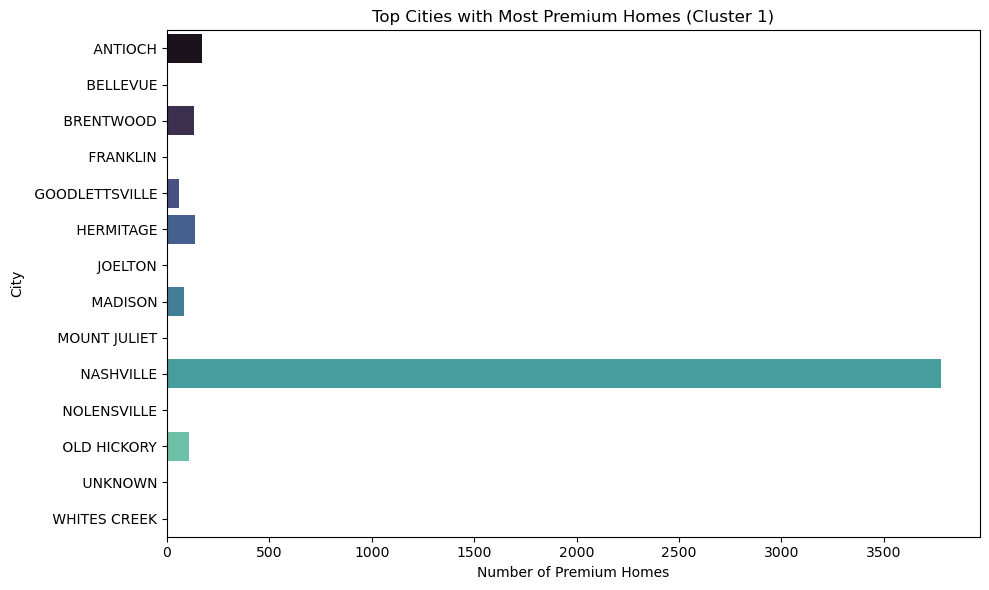

In [175]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(x=premium_by_city.values[:10], y=premium_by_city.index[:10], palette="mako")
plt.xlabel("Number of Premium Homes")
plt.ylabel("City")
plt.title("Top Cities with Most Premium Homes (Cluster 1)")
plt.tight_layout()
plt.show()


C:\Users\Akash\AppData\Local\Temp\ipykernel_27732\1110444300.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='SalePrice', data=housing_df, palette='coolwarm')


<Figure size 1000x600 with 0 Axes>

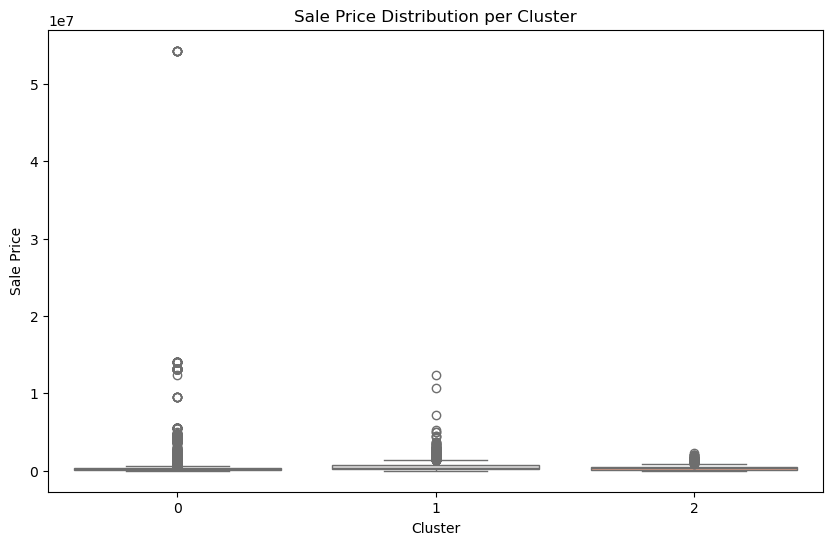

In [185]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='SalePrice', data=housing_df, palette='coolwarm')
plt.title("Sale Price Distribution per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Sale Price")
plt.show()


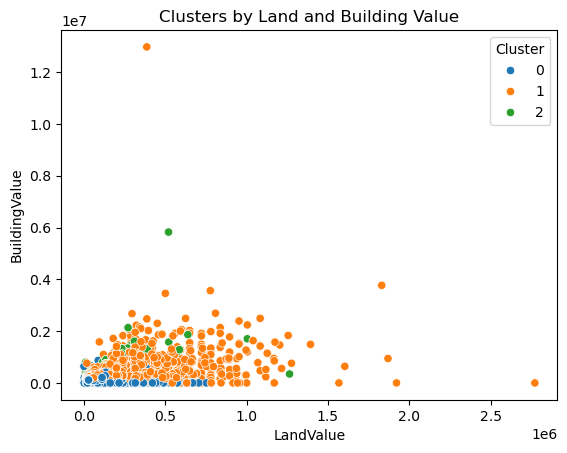

In [187]:
sns.scatterplot(data=housing_df, x='LandValue', y='BuildingValue', hue='Cluster', palette='tab10')
plt.title("Clusters by Land and Building Value")
plt.show()


In [177]:
# Filter to only premium homes (Cluster 1)
premium_homes = housing_df[housing_df['Cluster'] == 0]

# Count number of premium homes in each city
notpremium_by_city = premium_homes['Property_City'].value_counts().sort_values(ascending=False)

# Display top cities with most premium homes
print(notpremium_by_city.head(10))


Property_City
NASHVILLE         35645
ANTIOCH            6114
HERMITAGE          2989
MADISON            2022
BRENTWOOD          1560
OLD HICKORY        1306
GOODLETTSVILLE      675
NOLENSVILLE         493
MOUNT JULIET        178
WHITES CREEK         94
Name: count, dtype: int64


## Classification

In [56]:
housing_df['PriceCategory'] = pd.qcut(housing_df['SalePrice'], q=3, labels=['Low', 'Mid', 'High'])


In [58]:
not_required_features = [
    'SalePrice',             # Target source
    'UniqueID',
    'ParcelID',
    'LegalReference',
    'OwnerName',
    'Property_Address',
    'Owner-Address',
    'TotalValue'             # Possibly highly correlated with SalePrice
]


In [60]:
housing_df=housing_df.drop(columns=not_required_features,errors = 'ignore')

In [62]:
datetime_cols = housing_df.select_dtypes(include=['datetime64']).columns
housing_df = housing_df.drop(columns=datetime_cols)

In [64]:
X_input = housing_df.drop(columns=['PriceCategory'])
y = housing_df['PriceCategory']


In [66]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import pandas as pd

# Convert categorical variables into dummy/indicator variables
X = pd.get_dummies(X_input, drop_first=True)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



classTree = DecisionTreeClassifier(
    random_state=0,
    criterion='entropy',
    max_depth=8,            # Try 6–10
    min_samples_split=10,   # Prevents over-fragmentation
    min_samples_leaf=5      # Ensures leaves have enough data
)


classTree.fit(X_train, y_train)


DecisionTreeClassifier(criterion='entropy', max_depth=8, min_samples_leaf=5,
                       min_samples_split=10, random_state=0)

In [68]:
high_card_cols = [col for col in X_input.columns if X_input[col].nunique() > 100]
X_filtered = X_input.drop(columns=high_card_cols)
high_card_cols

['LandValue', 'BuildingValue', 'YearBuilt', 'New_Age']

In [70]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


In [72]:
confusion_matrix(y_test,classTree.predict(X_test))

array([[2671,  195,  837],
       [ 788, 2198,  798],
       [1002,  523, 2220]], dtype=int64)

In [74]:
from sklearn.model_selection import GridSearchCV

In [76]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Define parameter grid
grid_param = {
    'criterion': ['gini', 'entropy'],
    'max_depth': range(2, 15),
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Instantiate classifier
classTree = DecisionTreeClassifier(random_state=42)

# Grid Search
grid_search = GridSearchCV(estimator=classTree, 
                           param_grid=grid_param, 
                           cv=5, 
                           n_jobs=-1,
                           scoring='f1_weighted')  # Or 'accuracy'
grid_search.fit(X_train, y_train)

# Best results
print("Best parameters found:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)


Best parameters found: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best score: 0.6357290801559208


## Random Forest Classsifier

In [78]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Assume housing_df is preprocessed and includes 'PriceCategory' as target
X = housing_df.drop(columns=['PriceCategory'], errors='ignore')
y = housing_df['PriceCategory']

# Encode categoricals (after dropna or fillna)
X = pd.get_dummies(X, drop_first=True)

# Split and train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.ensemble import RandomForestClassifier



In [80]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
rf_model.fit(X_train, y_train)


RandomForestClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                       random_state=42)

In [82]:
 #Predict and evaluate
y_pred = rf_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.6371082621082621
              precision    recall  f1-score   support

        High       0.60      0.69      0.64      3703
         Low       0.74      0.62      0.68      3784
         Mid       0.59      0.60      0.59      3745

    accuracy                           0.64     11232
   macro avg       0.64      0.64      0.64     11232
weighted avg       0.65      0.64      0.64     11232



In [84]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score

# Set up parameter grid for tuning
grid_param = {
    'n_estimators': [100, 200],
    'max_depth': [8, 10, 12],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'criterion': ['gini', 'entropy']
}

# Instantiate Random Forest
rf_model = RandomForestClassifier(random_state=42)

# Set up GridSearch
grid_search = GridSearchCV(estimator=rf_model,
                           param_grid=grid_param,
                           cv=5,
                           n_jobs=-1,
                           verbose=1)

# Fit on training data
grid_search.fit(X_train, y_train)

# Best estimator
best_rf = grid_search.best_estimator_

# Predict
y_pred = best_rf.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Accuracy: 0.6443198005698005
              precision    recall  f1-score   support

        High       0.61      0.73      0.66      3703
         Low       0.76      0.61      0.68      3784
         Mid       0.59      0.60      0.59      3745

    accuracy                           0.64     11232
   macro avg       0.65      0.64      0.64     11232
weighted avg       0.65      0.64      0.64     11232



In [98]:
import pandas as pd

# New house details (just example numbers)
new_house = pd.DataFrame([{
    'LandValue': 850000,
    'BuildingValue': 1900000,
    'TotalValue': 2750000,
    'YearBuilt': 2012
}])


In [104]:

import pandas as pd

# New house details (just example numbers)
new_house = pd.DataFrame([{
    'LandValue': 850,
    'BuildingValue': 190,
    'TotalValue': 2750,
    'YearBuilt': 2012
}])


In [106]:
# This makes sure the new house has all the columns that the model expects
# X is the training data you used (after pd.get_dummies)
new_house_aligned = new_house.reindex(columns=X.columns, fill_value=0)


In [108]:
# Use the trained model to predict
prediction = best_rf.predict(new_house_aligned)

# Print the result
print("Predicted Price Category:", prediction[0])


Predicted Price Category: Low
